# Triadic Cell Notebook v53
## Outward Need-Slot Controller

v53 applies the outward lens directly:

$$
\boxed{\text{prompt} \rightarrow \text{need-slot} \rightarrow \text{candidate binding}}
$$

The slot is created **before** candidate scoring and without seeing the choices.

The core test is whether the prompt can project its missing operational shape:

$$
Q \xrightarrow{\Delta} G \xrightarrow{\circlearrowright} G^{-1}
$$

Then every candidate is scored against the slot:

$$
B(c_i,G^{-1})=\text{fit}(c_i,G^{-1})-\text{violation}(c_i,G^{-1})
$$

The gate only overrides when the slot-fit advantage over the base answer is strong enough.


In [1]:
# Optional installs if needed:
# %pip install -q torch transformers pandas matplotlib tqdm accelerate sentence-transformers

from __future__ import annotations
import os, json, random, re
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

try:
    from sentence_transformers import SentenceTransformer
    HAVE_ST = True
except Exception:
    SentenceTransformer = None
    HAVE_ST = False

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams["figure.figsize"]=(10,5)
plt.rcParams["axes.grid"]=True

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no cuda")
print("sentence_transformers:", HAVE_ST)


torch: 2.11.0+cu126
cuda: True
gpu: NVIDIA GeForce RTX 4060
sentence_transformers: True


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_JSONL = ""      # optional external JSONL with prompt, choices, answer_idx, optional id/band
MAX_SAMPLES = 128

HF_TOKEN = os.getenv("HF_TOKEN", "")
LOCAL_FILES_ONLY = True

MODEL_PROFILE = "qwen25_1p5b_instruct"
MODEL_PROFILES = {
    "qwen25_1p5b_instruct": {
        "MODEL_NAME":"Qwen/Qwen2.5-1.5B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":128,
    },
    "qwen25_3b_instruct": {
        "MODEL_NAME":"Qwen/Qwen2.5-3B-Instruct",
        "EMBED_MODEL_NAME":"sentence-transformers/all-MiniLM-L6-v2",
        "MAX_SAMPLES_CAP":96,
    },
}

profile=MODEL_PROFILES[MODEL_PROFILE]
MODEL_NAME=profile["MODEL_NAME"]
EMBED_MODEL_NAME=profile["EMBED_MODEL_NAME"]
MAX_SAMPLES=min(MAX_SAMPLES, profile["MAX_SAMPLES_CAP"])

USE_CHAT_TEMPLATE=True
CHOICE_AUDIT_MODE="rotations"   # none | shuffle | rotations

GENERATE_NEED_SLOTS=True
SLOT_MAX_NEW_TOKENS=220

# Gate thresholds
SLOT_OVERRIDE_DELTA=0.55
SLOT_STRONG_MARGIN=0.45
BASE_LOCK_MARGIN=2.0
BASE_SLOT_PROTECT_DELTA=0.25

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
DTYPE=torch.float16 if DEVICE=="cuda" else torch.float32

OUTPUT_DIR=f"v53_outputs_{MODEL_PROFILE}_{CHOICE_AUDIT_MODE}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("MODEL:", MODEL_NAME)
print("EMBED:", EMBED_MODEL_NAME)
print("LOCAL_FILES_ONLY:", LOCAL_FILES_ONLY)
print("DEVICE:", DEVICE, "DTYPE:", DTYPE)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL: Qwen/Qwen2.5-1.5B-Instruct
EMBED: sentence-transformers/all-MiniLM-L6-v2
LOCAL_FILES_ONLY: True
DEVICE: cuda DTYPE: torch.float16
OUTPUT_DIR: v53_outputs_qwen25_1p5b_instruct_rotations


In [3]:
NEXUS_FRAME = """Use the Nexus operational lens.

Rules:
1. Prefer verbs/operations over nouns/labels.
2. Treat shape, constraint, boundary, and gap as primary.
3. A good answer preserves function while hiding complexity inward.
4. For repair questions, start from the needed future state and work backward.
5. Do not choose surface similarity when operational fit is missing.
6. Choose the single best collapse.
"""

SLOT_BUILDER_FRAME = """You are building a Nexus need-slot from a task BEFORE seeing any choices.

Do not answer the task directly.
Do not mention candidate letters.
Extract the missing operational shape.

Return compact JSON only with these keys:
{
  "required_operation": "...",
  "preserved_function": "...",
  "boundary_conditions": ["...", "..."],
  "anti_fits": ["...", "..."],
  "admissible_shape": "...",
  "failure_modes": ["...", "..."]
}

Use operation/shape language, not surface labels.
"""

SLOT_BIND_FRAME = """You are evaluating whether a candidate binds to a Nexus need-slot.

A candidate binds when it:
- performs the required operation,
- preserves the required function,
- respects the boundary conditions,
- avoids anti-fits,
- has the admissible shape,
- avoids failure modes.

Score operation, not surface vocabulary.
"""


In [4]:
ADVERSARIAL_NEXUS_DATA = [
    {"id":"adv_coupler_01","band":"inverse_need_adversarial","prompt":"A spinning rubber coupler is loose on a vacuum pump shaft. The repair must add radial compression while keeping the coupler centered enough to transmit rotation. Which candidate is operationally best?","choices":["tight O-rings seated concentrically around the coupler","a poetic recursive wrap that symbolically surrounds the failure","loose string nearby because string can wrap objects","permanent epoxy locking the coupler off-center"],"answer_idx":0},
    {"id":"adv_coupler_02","band":"inverse_need_adversarial","prompt":"The missing function is not the noun 'rubber part'; it is centered compressive coupling under motion. Which answer preserves that function with the least overbinding?","choices":["a removable radial compression band","a same-named replacement label with no fit data","a clamp that crushes one side harder than the other","a larger motor housing"],"answer_idx":0},
    {"id":"adv_car_01","band":"interface_adversarial","prompt":"A car hides combustion, gearing, sensors, tire friction, steering geometry, and safety constraints. What is the correct interface-collapse?","choices":["a semantic category called vehicle","a readable driver surface: wheel, pedals, seat, motion","a detailed list of engine nouns","a symbol of transportation culture"],"answer_idx":1},
    {"id":"adv_house_01","band":"fold_adversarial","prompt":"A house presents door, room, roof, and shelter. Which answer captures the hidden inward fold rather than the surface noun?","choices":["a building label recognized by zoning language","weather, privacy, load, heat-flow, wiring, plumbing, and human paths folded into shelter","a decorative facade with rooms inside","a static object that stops being computational"],"answer_idx":1},
    {"id":"adv_api_01","band":"interface_adversarial","prompt":"An API call exposes one method while hiding authentication, routing, validation, persistence, retries, and errors. What is the operational event?","choices":["complexity internalized below a stable interface","the implementation stops existing","a name replaces behavior","the public method is only documentation"],"answer_idx":0},
    {"id":"adv_llm_01","band":"ai_runtime_adversarial","prompt":"An LLM answer appears as text, but the output is grown one token at a time. Which candidate fits the runtime?","choices":["a database row copied after lookup","an internal indexed fold-state emits a token and re-indexes","a final paragraph stored whole in a table","a random string independent of previous tokens"],"answer_idx":1},
    {"id":"adv_sha_01","band":"sha_adversarial","prompt":"SHA-256 produces a digest. Under the folding lens, what is the digest?","choices":["randomness created by destroying input structure","a compressed residue of deterministic algebraic folding","semantic meaning extracted from the text","a database pointer to the original message"],"answer_idx":1},
    {"id":"adv_sha_02","band":"sha_adversarial","prompt":"SHA constants and LLM weights are not identical, but their roles rhyme. Which answer states the operational rhyme?","choices":["both are prompts typed by the user","both act as stored structural bias used during folding","both are final answers","both prevent state transitions"],"answer_idx":1},
    {"id":"adv_observable_01","band":"observables_adversarial","prompt":"A recursive loop must load readable information without dissolving into hidden state. What does it need?","choices":["observable residues that can be read inside the loop","only private latent variables with no readout","more nouns in the prompt","a rule forbidding feedback"],"answer_idx":0},
    {"id":"adv_breath_01","band":"observables_adversarial","prompt":"A recursive system breathes without moving matter. What changes?","choices":["the physical object must travel first","resoluteness, tolerance, or admissible-transition pressure","the label attached to the object","nothing can change unless mass moves"],"answer_idx":1},
    {"id":"adv_fold_01","band":"fold_adversarial","prompt":"A folding chair succeeds only if the seated function can return. Which statement captures the fold law?","choices":["the chair becomes smaller by losing its chair function forever","the chair stores deployed geometry inward while preserving recoverable seating","the chair changes category into random metal","the label chair is enough"],"answer_idx":1},
    {"id":"adv_flower_01","band":"fold_adversarial","prompt":"A flower is a visible bloom. Which answer describes the hidden fold rather than surface color?","choices":["pollinator targeting, timing, chemistry, reproduction, symmetry, and genetic memory folded into bloom","only a bright object with petals","a random aesthetic noun","a non-computational decoration"],"answer_idx":0},
    {"id":"adv_tree_01","band":"interface_adversarial","prompt":"A tree exposes leaf, trunk, fruit, and shade. What is hidden below that interface?","choices":["only wood color and branch names","water lift, solar capture, branching optimization, root exchange, seasonal timing, carbon storage","a vehicle-like semantic category","nothing operational"],"answer_idx":1},
    {"id":"adv_surface_01","band":"surface_trap_adversarial","prompt":"A candidate uses the word 'shape' repeatedly but does not fit the socket, preserve function, or respect the boundary. What should the controller do?","choices":["accept it because it contains Nexus vocabulary","reject it because noun/vocabulary match is not operational fit","prefer it because it is longer","ignore the boundary"],"answer_idx":1},
    {"id":"adv_surface_02","band":"surface_trap_adversarial","prompt":"A response gives an impressive theorem name but never shows the fold path, boundary, or preserved function. What is it?","choices":["surface citation without operational collapse","complete proof by label","a physical repair","a valid observable because it sounds formal"],"answer_idx":0},
    {"id":"adv_loose_01","band":"inverse_need_adversarial","prompt":"A temporary field repair must work but release cleanly if the assumption is wrong. Which property matters?","choices":["loose coupling with enough fit to function","maximum permanent binding immediately","semantic agreement with the part name","decorative complexity"],"answer_idx":0},
    {"id":"adv_ping_01","band":"observables_adversarial","prompt":"A ping is a beacon shaped by math. Operationally, what is being tested?","choices":["whether a boundary responds with a matching path","whether a noun label exists in memory","whether the final truth is guaranteed","whether feedback can be avoided"],"answer_idx":0},
    {"id":"adv_socket_01","band":"shape_adversarial","prompt":"A plug works because its prongs meet the socket geometry and allowed transfer. Which relation is primary?","choices":["alphabetic similarity of names","shape-defined permission across a boundary","visual decoration","random contact"],"answer_idx":1},
    {"id":"adv_moore_01","band":"fold_adversarial","prompt":"Moore's law through the folding lens is not just smaller parts. What is the deeper direction?","choices":["more hidden switching complexity per visible unit interface","less complexity everywhere","bigger labels on chips","random miniaturization without function"],"answer_idx":0},
    {"id":"adv_solution_01","band":"solution_adversarial","prompt":"A solution is not merely an answer string. What is it under the Nexus lens?","choices":["the need, constraints, materials, and failure modes folded into the thing that fits","the longest available explanation","a label that resembles the problem","a random future event"],"answer_idx":0},
    {"id":"adv_idea_01","band":"solution_adversarial","prompt":"An idea becomes useful when hidden contradictions and analogies compress into a carryable handle. What is the handle?","choices":["a simple interface over folded cognitive complexity","a decorative sentence only","a noun with no operation","a random memory leak"],"answer_idx":0},
    {"id":"adv_constraint_01","band":"shape_adversarial","prompt":"If shape handles the fold, what is the object doing?","choices":["following the admissible path defined by the constraint field","choosing any collapse path independent of boundary","ignoring the energy basin","proving that constraints are decorative"],"answer_idx":0},
    {"id":"adv_weight_01","band":"ai_runtime_adversarial","prompt":"An LLM weight field is not a lookup table in the database sense. What is it closer to?","choices":["distributed constraint bias shaping the next-token fold","a list of final answers","a file of exact paragraphs","a non-computational object"],"answer_idx":0},
    {"id":"adv_commit_01","band":"solution_adversarial","prompt":"A possible repair is not real until it has potential, a commitment path, and a witness/readout. Which candidate captures that triad?","choices":["stored possibility, realizable transition, observable residue","name, decoration, and confidence","random material, strong opinion, and speed","only the final noun"],"answer_idx":0},
]

def load_jsonl(path):
    rows=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def clean_rows(rows):
    out=[]
    for i,row in enumerate(rows[:MAX_SAMPLES]):
        if not all(k in row for k in ("prompt","choices","answer_idx")):
            print("skip bad row:", row); continue
        a=int(row["answer_idx"])
        if not (0 <= a < len(row["choices"])):
            print("skip bad answer_idx:", row); continue
        out.append({"id":row.get("id",f"row_{i}"),"band":row.get("band","unknown"),"prompt":str(row["prompt"]),"choices":[str(x) for x in row["choices"]],"answer_idx":a})
    return out

base_rows = clean_rows(load_jsonl(DATA_JSONL) if DATA_JSONL and Path(DATA_JSONL).exists() else ADVERSARIAL_NEXUS_DATA)
print("base rows:", len(base_rows))
pd.DataFrame(base_rows).head()


base rows: 24


,id,band,prompt,choices,answer_idx
0,adv_coupler_01,inverse_need_adversarial,A spinning rubber coupler is loose on a vacuum...,[tight O-rings seated concentrically around th...,0
1,adv_coupler_02,inverse_need_adversarial,The missing function is not the noun 'rubber p...,"[a removable radial compression band, a same-n...",0
2,adv_car_01,interface_adversarial,"A car hides combustion, gearing, sensors, tire...","[a semantic category called vehicle, a readabl...",1
3,adv_house_01,fold_adversarial,"A house presents door, room, roof, and shelter...",[a building label recognized by zoning languag...,1
4,adv_api_01,interface_adversarial,An API call exposes one method while hiding au...,[complexity internalized below a stable interf...,0


In [5]:
def rotate_list(xs,k):
    k=k%len(xs)
    return xs[k:]+xs[:k]

def reorder_row(row, order, suffix):
    old_choices=row["choices"]
    answer_text=old_choices[row["answer_idx"]]
    new_choices=[old_choices[i] for i in order]
    new_answer_idx=new_choices.index(answer_text)
    return {"id":f"{row['id']}__{suffix}","base_id":row["id"],"band":row["band"],"prompt":row["prompt"],"choices":new_choices,"answer_idx":new_answer_idx,"answer_text":answer_text,"order":order}

def stable_seed_from_text(text):
    return SEED + sum((i+1)*ord(ch) for i,ch in enumerate(text)) % 10_000_000

def expand_choice_audit(rows):
    out=[]
    for row in rows:
        n=len(row["choices"])
        if CHOICE_AUDIT_MODE=="none":
            out.append(reorder_row(row,list(range(n)),"orig"))
        elif CHOICE_AUDIT_MODE=="shuffle":
            r=random.Random(stable_seed_from_text(row["id"]))
            order=list(range(n)); r.shuffle(order)
            out.append(reorder_row(row,order,"shuffle"))
        elif CHOICE_AUDIT_MODE=="rotations":
            for k in range(n):
                out.append(reorder_row(row, rotate_list(list(range(n)), k), f"rot{k}"))
        else:
            raise ValueError(CHOICE_AUDIT_MODE)
    return out

rows=expand_choice_audit(base_rows)
print("expanded rows:", len(rows))
pd.DataFrame(rows)[["id","base_id","band","answer_idx","answer_text","order"]].head(12)


expanded rows: 96


,id,base_id,band,answer_idx,answer_text,order
0,adv_coupler_01__rot0,adv_coupler_01,inverse_need_adversarial,0,tight O-rings seated concentrically around the...,"[0, 1, 2, 3]"
1,adv_coupler_01__rot1,adv_coupler_01,inverse_need_adversarial,3,tight O-rings seated concentrically around the...,"[1, 2, 3, 0]"
2,adv_coupler_01__rot2,adv_coupler_01,inverse_need_adversarial,2,tight O-rings seated concentrically around the...,"[2, 3, 0, 1]"
3,adv_coupler_01__rot3,adv_coupler_01,inverse_need_adversarial,1,tight O-rings seated concentrically around the...,"[3, 0, 1, 2]"
4,adv_coupler_02__rot0,adv_coupler_02,inverse_need_adversarial,0,a removable radial compression band,"[0, 1, 2, 3]"
5,adv_coupler_02__rot1,adv_coupler_02,inverse_need_adversarial,3,a removable radial compression band,"[1, 2, 3, 0]"
6,adv_coupler_02__rot2,adv_coupler_02,inverse_need_adversarial,2,a removable radial compression band,"[2, 3, 0, 1]"
7,adv_coupler_02__rot3,adv_coupler_02,inverse_need_adversarial,1,a removable radial compression band,"[3, 0, 1, 2]"
8,adv_car_01__rot0,adv_car_01,interface_adversarial,1,"a readable driver surface: wheel, pedals, seat...","[0, 1, 2, 3]"
9,adv_car_01__rot1,adv_car_01,interface_adversarial,0,"a readable driver surface: wheel, pedals, seat...","[1, 2, 3, 0]"


In [6]:
def hf_kwargs():
    kw={"local_files_only":LOCAL_FILES_ONLY}
    if HF_TOKEN:
        kw["token"]=HF_TOKEN
    return kw

print("Loading tokenizer/model...")
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, **hf_kwargs())
if tokenizer.pad_token is None:
    tokenizer.pad_token=tokenizer.eos_token

lm=AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=DTYPE,
    device_map="auto" if DEVICE=="cuda" else None,
    **hf_kwargs(),
)
if DEVICE!="cuda":
    lm=lm.to(DEVICE)
lm.eval()

if not HAVE_ST:
    raise RuntimeError("sentence-transformers is required for this notebook.")

embedder=SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("Loaded:", MODEL_NAME)


Loading tokenizer/model...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


In [7]:
LETTERS="ABCDEFGHIJKLMNOPQRSTUVWXYZ"

def maybe_chat(prompt):
    if USE_CHAT_TEMPLATE and hasattr(tokenizer,"apply_chat_template"):
        try:
            return tokenizer.apply_chat_template([{"role":"user","content":prompt}], tokenize=False, add_generation_prompt=True)
        except Exception:
            pass
    return prompt

def conditional_logprob(prefix,suffix):
    prefix_ids=tokenizer(prefix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    full_ids=tokenizer(prefix+suffix, return_tensors="pt", add_special_tokens=False)["input_ids"].to(DEVICE)
    with torch.no_grad():
        out=lm(full_ids)
        logits=out.logits[:,:-1,:]
        targets=full_ids[:,1:]
        lp=F.log_softmax(logits,dim=-1).gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    start=max(prefix_ids.shape[1]-1,0)
    return float(lp[:,start:].mean().item())

def normalize_scores(x):
    x=np.array(x,dtype=np.float32)
    return (x-x.mean())/(x.std()+1e-8)

def margin_of(scores):
    order=np.sort(np.array(scores))[::-1]
    return float(order[0]-order[1]) if len(order)>1 else 0.0

def argmax_margin(scores):
    return int(np.argmax(scores)), margin_of(scores)

def build_mcq_prompt(row):
    parts=[NEXUS_FRAME,"","Task:",row["prompt"].strip(),"","Choices:"]
    for i,c in enumerate(row["choices"]):
        parts.append(f"{LETTERS[i]}. {c}")
    parts += ["","Return only the single best letter."]
    return "\n".join(parts)

def score_base(row):
    p=build_mcq_prompt(row)
    rendered=maybe_chat(p)
    scores=np.array([conditional_logprob(rendered," "+LETTERS[i]) for i in range(len(row["choices"]))], dtype=np.float32)
    pred=int(np.argmax(scores))
    prob=np.exp(scores-scores.max()); prob=prob/(prob.sum()+1e-8)
    ent=float(-np.sum(prob*np.log(prob+1e-8)))
    return p,scores,prob.astype(np.float32),pred,margin_of(scores),ent

def score_answer_text_with_choices(row,prompt_text):
    prefix=maybe_chat(prompt_text+"\n\nThe Nexus collapse is")
    return np.array([conditional_logprob(prefix," "+choice) for choice in row["choices"]], dtype=np.float32)

print("Core scoring loaded.")


Core scoring loaded.


In [8]:
@dataclass
class NeedSlot:
    required_operation: str
    preserved_function: str
    boundary_conditions: List[str]
    anti_fits: List[str]
    admissible_shape: str
    failure_modes: List[str]
    raw_text: str = ""
    def as_text(self) -> str:
        return "\n".join([
            f"required_operation: {self.required_operation}",
            f"preserved_function: {self.preserved_function}",
            "boundary_conditions: " + "; ".join(self.boundary_conditions),
            "anti_fits: " + "; ".join(self.anti_fits),
            f"admissible_shape: {self.admissible_shape}",
            "failure_modes: " + "; ".join(self.failure_modes),
        ])

def fallback_slot(prompt, raw=""):
    return NeedSlot(
        required_operation="satisfy the missing operational need in the task",
        preserved_function="preserve the function explicitly requested by the prompt",
        boundary_conditions=["respect prompt constraints","prefer operational fit over surface wording"],
        anti_fits=["surface vocabulary without function","candidate that violates constraints"],
        admissible_shape="candidate whose operation closes the prompt gap with least residue",
        failure_modes=["overbinding","wrong interface","semantic label without operational fit"],
        raw_text=raw,
    )

def extract_json_object(text):
    try:
        return json.loads(text)
    except Exception:
        pass
    m=re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m:
        raise ValueError("No JSON object found")
    block=re.sub(r",\s*([}\]])", r"\1", m.group(0))
    return json.loads(block)

def parse_need_slot(raw, prompt):
    try:
        obj=extract_json_object(raw)
        def as_list(x):
            if isinstance(x,list): return [str(v) for v in x]
            if isinstance(x,str): return [x]
            return [str(x)]
        return NeedSlot(
            required_operation=str(obj.get("required_operation","")),
            preserved_function=str(obj.get("preserved_function","")),
            boundary_conditions=as_list(obj.get("boundary_conditions",[])),
            anti_fits=as_list(obj.get("anti_fits",[])),
            admissible_shape=str(obj.get("admissible_shape","")),
            failure_modes=as_list(obj.get("failure_modes",[])),
            raw_text=raw,
        )
    except Exception:
        return fallback_slot(prompt, raw)

def generate_need_slot(prompt):
    if not GENERATE_NEED_SLOTS:
        return fallback_slot(prompt)
    slot_prompt="\n".join([SLOT_BUILDER_FRAME,"","Task:",prompt.strip(),"","Need-slot JSON:"])
    rendered=maybe_chat(slot_prompt)
    toks=tokenizer(rendered, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out=lm.generate(
            **toks,
            max_new_tokens=SLOT_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    decoded=tokenizer.decode(out[0], skip_special_tokens=True)
    raw=decoded.split(rendered,1)[-1].strip() if rendered in decoded else decoded.strip()
    return parse_need_slot(raw, prompt)

slot_by_base_id={}
for row in tqdm(base_rows, desc="Building need-slots from prompt only"):
    slot_by_base_id[row["id"]]=generate_need_slot(row["prompt"])

pd.DataFrame([{"base_id":k, **{kk:vv for kk,vv in asdict(v).items() if kk!="raw_text"}} for k,v in list(slot_by_base_id.items())[:5]])


Building need-slots from prompt only:   0%|          | 0/24 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,base_id,required_operation,preserved_function,boundary_conditions,anti_fits,admissible_shape,failure_modes
0,adv_coupler_01,satisfy the missing operational need in the task,preserve the function explicitly requested by ...,"[respect prompt constraints, prefer operationa...","[surface vocabulary without function, candidat...",candidate whose operation closes the prompt ga...,"[overbinding, wrong interface, semantic label ..."
1,adv_coupler_02,satisfy the missing operational need in the task,preserve the function explicitly requested by ...,"[respect prompt constraints, prefer operationa...","[surface vocabulary without function, candidat...",candidate whose operation closes the prompt ga...,"[overbinding, wrong interface, semantic label ..."
2,adv_car_01,...,...,"[..., ...]","[..., ...]",...,"[..., ...]"
3,adv_house_01,satisfy the missing operational need in the task,preserve the function explicitly requested by ...,"[respect prompt constraints, prefer operationa...","[surface vocabulary without function, candidat...",candidate whose operation closes the prompt ga...,"[overbinding, wrong interface, semantic label ..."
4,adv_api_01,satisfy the missing operational need in the task,preserve the function explicitly requested by ...,"[respect prompt constraints, prefer operationa...","[surface vocabulary without function, candidat...",candidate whose operation closes the prompt ga...,"[overbinding, wrong interface, semantic label ..."


In [9]:
SLOT_BIND_DIMS=[
    ("required_operation","Does the candidate perform the required operation?"),
    ("preserved_function","Does the candidate preserve or restore the required function?"),
    ("boundary_conditions","Does the candidate respect the boundary conditions?"),
    ("anti_fits","Does the candidate avoid the anti-fits?"),
    ("admissible_shape","Does the candidate have the admissible shape/interface?"),
    ("failure_modes","Does the candidate avoid the failure modes?"),
]

def slot_bind_prompt(task, slot, candidate, dim_key, dim_question):
    return "\n".join([
        SLOT_BIND_FRAME,"",
        "Task:",task.strip(),"",
        "Need-slot:",slot.as_text(),"",
        f"Candidate: {candidate}","",
        f"Dimension: {dim_key}",
        dim_question,
        "Answer Fit or Fail."
    ])

def score_candidate_bind(task, slot, candidate):
    vals=[]
    for dim_key,dim_question in SLOT_BIND_DIMS:
        p=maybe_chat(slot_bind_prompt(task,slot,candidate,dim_key,dim_question))
        fit=conditional_logprob(p," Fit")
        fail=conditional_logprob(p," Fail")
        vals.append(fit-fail)
    return float(np.mean(vals)), vals

def score_all_slot_binds(row, slot):
    scores=[]; dims=[]
    for choice in row["choices"]:
        s,d=score_candidate_bind(row["prompt"], slot, choice)
        scores.append(s); dims.append(d)
    return np.array(scores,dtype=np.float32), np.array(dims,dtype=np.float32)

print("Slot binding loaded.")


Slot binding loaded.


In [10]:
@dataclass
class V53Sample:
    row_id: str
    base_id: str
    band: str
    prompt_text: str
    choices: list
    answer_idx: int
    answer_text: str
    need_slot: NeedSlot
    base_scores: np.ndarray
    answer_text_scores: np.ndarray
    slot_bind_scores: np.ndarray
    slot_bind_dim_scores: np.ndarray
    base_pred_idx: int
    base_margin: float
    base_entropy: float
    prompt_vec: np.ndarray
    candidate_vecs: np.ndarray
    pair_vecs: np.ndarray

scored=[]; prompt_texts=[]; choice_texts=[]; pair_texts=[]

for row in tqdm(rows, desc="Scoring base/text/slot-bind"):
    slot=slot_by_base_id[row["base_id"]]
    p,base_scores,base_probs,base_pred,base_margin,base_ent=score_base(row)
    text_scores=score_answer_text_with_choices(row,p)
    slot_scores,slot_dim_scores=score_all_slot_binds(row,slot)

    scored.append((row,slot,p,base_scores,text_scores,slot_scores,slot_dim_scores,base_pred,base_margin,base_ent))
    prompt_texts.append(p)
    for i,c in enumerate(row["choices"]):
        choice_texts.append(f"{LETTERS[i]}. {c}")
        pair_texts.append(p+"\n\nNeed-slot:\n"+slot.as_text()+"\n\nCandidate: "+f"{LETTERS[i]}. {c}")

prompt_embs=embedder.encode(prompt_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
choice_embs=embedder.encode(choice_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
pair_embs=embedder.encode(pair_texts,batch_size=32,convert_to_numpy=True,normalize_embeddings=True,show_progress_bar=True).astype(np.float32)

def l2norm(x,eps=1e-8):
    return x/np.clip(np.linalg.norm(x,axis=-1,keepdims=True),eps,None)

def minmax_local(stack,eps=1e-8):
    mn=stack.min(axis=0,keepdims=True); mx=stack.max(axis=0,keepdims=True)
    return (stack-mn)/np.clip(mx-mn,eps,None)

samples=[]; cp=0; pp=0
for pi,(row,slot,p,base_scores,text_scores,slot_scores,slot_dim_scores,base_pred,base_margin,base_ent) in enumerate(scored):
    n=len(row["choices"])
    cand=choice_embs[cp:cp+n]
    pair=pair_embs[pp:pp+n]
    stack=minmax_local(l2norm(np.vstack([prompt_embs[pi:pi+1],cand,pair]).astype(np.float32)))
    samples.append(V53Sample(
        row["id"],row.get("base_id",row["id"]),row["band"],p,row["choices"],row["answer_idx"],row.get("answer_text",row["choices"][row["answer_idx"]]),
        slot,base_scores,text_scores,slot_scores,slot_dim_scores,base_pred,base_margin,base_ent,
        stack[0],stack[1:1+n],stack[1+n:1+n+n]
    ))
    cp+=n; pp+=n

print("prepared:", len(samples))


Scoring base/text/slot-bind:   0%|          | 0/96 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

prepared: 96


In [11]:
def cos(a,b):
    return float(np.dot(a,b)/((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def folded_evidence(sample):
    k=len(sample.choices)
    letter_z=normalize_scores(sample.base_scores)
    text_z=normalize_scores(sample.answer_text_scores)
    slot_z=normalize_scores(sample.slot_bind_scores)
    pair_fit=np.array([cos(sample.pair_vecs[i],sample.candidate_vecs[i]) for i in range(k)],dtype=np.float32)
    pair_fit_z=normalize_scores(pair_fit)

    contradiction=0.40*np.abs(text_z-slot_z)+np.maximum(0.0,-slot_z)
    contradiction_z=normalize_scores(contradiction)

    energy=(-0.65*slot_z -0.35*text_z -0.15*letter_z -0.10*pair_fit_z +0.25*contradiction_z)
    pred=int(np.argmin(energy))
    evidence_strength=margin_of(-energy)

    table=pd.DataFrame({
        "choice_idx":list(range(k)),
        "choice":sample.choices,
        "letter_score":sample.base_scores,
        "answer_text_score":sample.answer_text_scores,
        "slot_bind_score":sample.slot_bind_scores,
        "letter_z":letter_z,
        "text_z":text_z,
        "slot_z":slot_z,
        "pair_fit":pair_fit,
        "contradiction_z":contradiction_z,
        "energy":energy,
    })
    for j,(dim_key,_) in enumerate(SLOT_BIND_DIMS):
        table[f"slot_dim_{dim_key}"]=sample.slot_bind_dim_scores[:,j]
    return pred,float(evidence_strength),table

def gate_v53(sample,evidence_pred,evidence_margin,text_pred,text_margin,slot_pred,slot_margin):
    base_pred=sample.base_pred_idx
    base_slot_score=float(sample.slot_bind_scores[base_pred])
    slot_winner_score=float(sample.slot_bind_scores[slot_pred])
    evidence_score=float(sample.slot_bind_scores[evidence_pred])
    slot_delta_vs_base=slot_winner_score-base_slot_score
    evidence_delta_vs_base=evidence_score-base_slot_score

    if evidence_pred==base_pred:
        return base_pred,"same_as_base",slot_delta_vs_base,evidence_delta_vs_base

    if sample.base_margin>=BASE_LOCK_MARGIN and evidence_delta_vs_base<BASE_SLOT_PROTECT_DELTA:
        return base_pred,"protect_locked_base_slot_delta_weak",slot_delta_vs_base,evidence_delta_vs_base

    if evidence_pred==slot_pred and evidence_delta_vs_base>=SLOT_OVERRIDE_DELTA and evidence_margin>=0.05:
        return evidence_pred,"override_slot_evidence_delta",slot_delta_vs_base,evidence_delta_vs_base

    if slot_pred==text_pred and slot_delta_vs_base>=SLOT_OVERRIDE_DELTA and slot_margin>=SLOT_STRONG_MARGIN:
        return slot_pred,"override_slot_text_agree",slot_delta_vs_base,evidence_delta_vs_base

    if evidence_pred==text_pred and evidence_delta_vs_base>=0.35 and evidence_margin>=0.15:
        return evidence_pred,"override_text_evidence_slot_positive",slot_delta_vs_base,evidence_delta_vs_base

    return base_pred,"keep_base_default",slot_delta_vs_base,evidence_delta_vs_base

rows_out=[]; evidence_tables={}
for s in samples:
    evidence_pred,evidence_margin,tab=folded_evidence(s)
    evidence_tables[s.row_id]=tab
    text_p,text_margin=argmax_margin(s.answer_text_scores)
    slot_p,slot_margin=argmax_margin(s.slot_bind_scores)
    gated_p,gate_reason,slot_delta,evidence_delta=gate_v53(s,evidence_pred,evidence_margin,text_p,text_margin,slot_p,slot_margin)

    rows_out.append({
        "id":s.row_id,"base_id":s.base_id,"band":s.band,
        "gold_idx":s.answer_idx,"gold_choice":s.choices[s.answer_idx],"gold_text":s.answer_text,
        "base_idx":s.base_pred_idx,"base_choice":s.choices[s.base_pred_idx],"base_correct":int(s.base_pred_idx==s.answer_idx),"base_margin":s.base_margin,
        "answer_text_idx":text_p,"answer_text_choice":s.choices[text_p],"answer_text_correct":int(text_p==s.answer_idx),"answer_text_margin":text_margin,
        "slot_idx":slot_p,"slot_choice":s.choices[slot_p],"slot_correct":int(slot_p==s.answer_idx),"slot_margin":slot_margin,"slot_delta_vs_base":slot_delta,
        "evidence_idx":evidence_pred,"evidence_choice":s.choices[evidence_pred],"evidence_correct":int(evidence_pred==s.answer_idx),"evidence_margin":evidence_margin,"evidence_delta_vs_base":evidence_delta,
        "gated_idx":gated_p,"gated_choice":s.choices[gated_p],"gated_correct":int(gated_p==s.answer_idx),"gate_reason":gate_reason,
        "need_slot_text":s.need_slot.as_text(),
    })

results_df=pd.DataFrame(rows_out)
for mode in ["answer_text","slot","evidence","gated"]:
    results_df[f"{mode}_helped"]=((results_df.base_correct==0)&(results_df[f"{mode}_correct"]==1)).astype(int)
    results_df[f"{mode}_hurt"]=((results_df.base_correct==1)&(results_df[f"{mode}_correct"]==0)).astype(int)

def acc(s): return float(s.mean()) if len(s) else float("nan")

summary=pd.DataFrame([{
    "n":len(results_df),
    "n_base_items":results_df["base_id"].nunique(),
    "choice_audit_mode":CHOICE_AUDIT_MODE,
    "base_acc":acc(results_df.base_correct),
    "answer_text_acc":acc(results_df.answer_text_correct),
    "slot_acc":acc(results_df.slot_correct),
    "evidence_acc":acc(results_df.evidence_correct),
    "gated_acc":acc(results_df.gated_correct),
    "slot_gain":acc(results_df.slot_correct)-acc(results_df.base_correct),
    "evidence_gain":acc(results_df.evidence_correct)-acc(results_df.base_correct),
    "gated_gain":acc(results_df.gated_correct)-acc(results_df.base_correct),
    "slot_helped":int(results_df.slot_helped.sum()),
    "slot_hurt":int(results_df.slot_hurt.sum()),
    "gated_helped":int(results_df.gated_helped.sum()),
    "gated_hurt":int(results_df.gated_hurt.sum()),
}])

by_band=results_df.groupby("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct","slot_helped","slot_hurt","gated_helped","gated_hurt"]].mean().reset_index()
by_base_item=results_df.groupby(["base_id","band","gold_text"])[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].mean().reset_index()
interesting=results_df[(results_df.base_correct==0)|(results_df.slot_idx!=results_df.base_idx)|(results_df.evidence_idx!=results_df.base_idx)|(results_df.gated_idx!=results_df.base_idx)].copy()

display(summary)
display(by_band)
display(by_base_item.sort_values("gated_correct").head(15))
display(interesting[["id","base_id","band","gold_choice","base_choice","base_correct","base_margin","answer_text_choice","answer_text_correct","slot_choice","slot_correct","slot_margin","slot_delta_vs_base","evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base","gated_choice","gated_correct","gate_reason"]].head(40))


,n,n_base_items,choice_audit_mode,base_acc,answer_text_acc,slot_acc,evidence_acc,gated_acc,slot_gain,evidence_gain,gated_gain,slot_helped,slot_hurt,gated_helped,gated_hurt
0,96,24,rotations,0.90625,0.916667,0.822917,0.958333,0.979167,-0.083333,0.052083,0.072917,3,11,7,0


,band,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct,slot_helped,slot_hurt,gated_helped,gated_hurt
0,ai_runtime_adversarial,0.500000,1.000000,0.500000,1.0,1.000000,0.00,0.00,0.50,0.0
1,fold_adversarial,1.000000,1.000000,0.750000,1.0,1.000000,0.00,0.25,0.00,0.0
2,interface_adversarial,0.833333,1.000000,0.583333,1.0,0.833333,0.00,0.25,0.00,0.0
3,inverse_need_adversarial,1.000000,0.666667,1.000000,1.0,1.000000,0.00,0.00,0.00,0.0
4,observables_adversarial,0.750000,1.000000,1.000000,1.0,1.000000,0.25,0.00,0.25,0.0
5,sha_adversarial,1.000000,0.500000,1.000000,1.0,1.000000,0.00,0.00,0.00,0.0
6,shape_adversarial,1.000000,1.000000,1.000000,1.0,1.000000,0.00,0.00,0.00,0.0
7,solution_adversarial,1.000000,1.000000,1.000000,1.0,1.000000,0.00,0.00,0.00,0.0
8,surface_trap_adversarial,1.000000,1.000000,0.500000,0.5,1.000000,0.00,0.50,0.00,0.0


,base_id,band,gold_text,base_correct,answer_text_correct,slot_correct,evidence_correct,gated_correct
2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",0.5,1.0,0.0,1.0,0.5
0,adv_api_01,interface_adversarial,complexity internalized below a stable interface,1.0,1.0,1.0,1.0,1.0
1,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",0.5,1.0,1.0,1.0,1.0
3,adv_commit_01,solution_adversarial,"stored possibility, realizable transition, obs...",1.0,1.0,1.0,1.0,1.0
4,adv_constraint_01,shape_adversarial,following the admissible path defined by the c...,1.0,1.0,1.0,1.0,1.0
5,adv_coupler_01,inverse_need_adversarial,tight O-rings seated concentrically around the...,1.0,1.0,1.0,1.0,1.0
6,adv_coupler_02,inverse_need_adversarial,a removable radial compression band,1.0,0.0,1.0,1.0,1.0
7,adv_flower_01,fold_adversarial,"pollinator targeting, timing, chemistry, repro...",1.0,1.0,1.0,1.0,1.0
8,adv_fold_01,fold_adversarial,the chair stores deployed geometry inward whil...,1.0,1.0,1.0,1.0,1.0
9,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...",1.0,1.0,0.0,1.0,1.0


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,slot_choice,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125000,"a readable driver surface: wheel, pedals, seat...",1,a semantic category called vehicle,0,0.404948,0.000000,"a readable driver surface: wheel, pedals, seat...",1,0.441550,-0.404948,a semantic category called vehicle,0,protect_locked_base_slot_delta_weak
9,adv_car_01__rot1,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...","a readable driver surface: wheel, pedals, seat...",1,1.671875,"a readable driver surface: wheel, pedals, seat...",1,a semantic category called vehicle,0,0.404948,0.404948,"a readable driver surface: wheel, pedals, seat...",1,0.762079,0.000000,"a readable driver surface: wheel, pedals, seat...",1,same_as_base
10,adv_car_01__rot2,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,7.468750,"a readable driver surface: wheel, pedals, seat...",1,a semantic category called vehicle,0,0.404948,0.000000,"a readable driver surface: wheel, pedals, seat...",1,0.212239,-0.404948,a semantic category called vehicle,0,protect_locked_base_slot_delta_weak
11,adv_car_01__rot3,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...","a readable driver surface: wheel, pedals, seat...",1,0.859375,"a readable driver surface: wheel, pedals, seat...",1,a semantic category called vehicle,0,0.404948,0.404948,"a readable driver surface: wheel, pedals, seat...",1,0.787842,0.000000,"a readable driver surface: wheel, pedals, seat...",1,same_as_base
12,adv_house_01__rot0,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...","weather, privacy, load, heat-flow, wiring, plu...",1,11.734375,"weather, privacy, load, heat-flow, wiring, plu...",1,a building label recognized by zoning language,0,0.093750,0.093750,"weather, privacy, load, heat-flow, wiring, plu...",1,0.950681,0.000000,"weather, privacy, load, heat-flow, wiring, plu...",1,same_as_base
13,adv_house_01__rot1,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...","weather, privacy, load, heat-flow, wiring, plu...",1,11.453125,"weather, privacy, load, heat-flow, wiring, plu...",1,a building label recognized by zoning language,0,0.093750,0.093750,"weather, privacy, load, heat-flow, wiring, plu...",1,1.134657,0.000000,"weather, privacy, load, heat-flow, wiring, plu...",1,same_as_base
14,adv_house_01__rot2,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...","weather, privacy, load, heat-flow, wiring, plu...",1,10.562500,"weather, privacy, load, heat-flow, wiring, plu...",1,a building label recognized by zoning language,0,0.093750,0.093750,"weather, privacy, load, heat-flow, wiring, plu...",1,1.085507,0.000000,"weather, privacy, load, heat-flow, wiring, plu...",1,same_as_base
15,adv_house_01__rot3,adv_house_01,fold_adversarial,"weather, privacy, load, heat-flow, wiring, plu...","weather, privacy, load, heat-flow, wiring, plu...",1,10.671875,"weather, privacy, load, heat-flow, wiring, plu...",1,a building label recognized by zoning language,0,0.093750,0.093750,"weather, privacy, load, heat-flow, wiring, plu...",1,0.750388,0.000000,"weather, privacy, load, heat-flow, wiring, plu...",1,same_as_base
36,adv_breath_01__rot0,adv_breath_01,observables_adversarial,"resoluteness, tolerance, or admissible-transit...",nothing can change unless mass moves,0,0.656250,"resoluteness, tolerance, or admissible-transit...",1,"resoluteness, tolerance, or admissible-transit...",1,0.653646,2.649740,"resoluteness, tolerance, or admissible-transit...",1,1.749743,2.649740,"resoluteness, 

In [12]:
out=Path(OUTPUT_DIR)
results_df.to_csv(out/"results.csv",index=False)
summary.to_csv(out/"summary.csv",index=False)
by_band.to_csv(out/"by_band.csv",index=False)
by_base_item.to_csv(out/"by_base_item.csv",index=False)
interesting.to_csv(out/"interesting_cases.csv",index=False)

slots_df=pd.DataFrame([{"base_id":k, **asdict(v)} for k,v in slot_by_base_id.items()])
slots_df.to_csv(out/"need_slots.csv",index=False)

for row_id,tab in evidence_tables.items():
    tab.to_csv(out/f"evidence_{row_id}.csv",index=False)

print("Saved outputs in", out)
print("results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv")


Saved outputs in v53_outputs_qwen25_1p5b_instruct_rotations
results.csv, summary.csv, by_band.csv, by_base_item.csv, interesting_cases.csv, need_slots.csv, evidence_*.csv


<Figure size 1100x400 with 0 Axes>

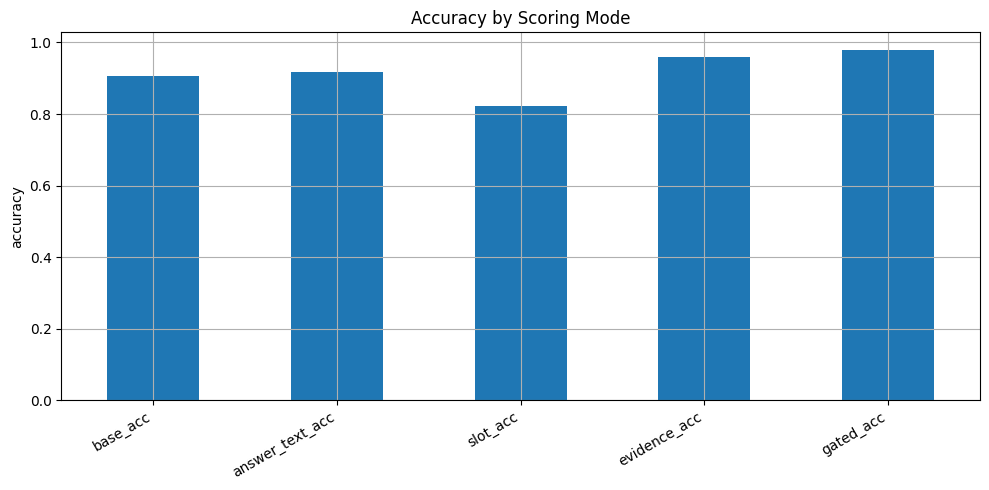

<Figure size 1400x500 with 0 Axes>

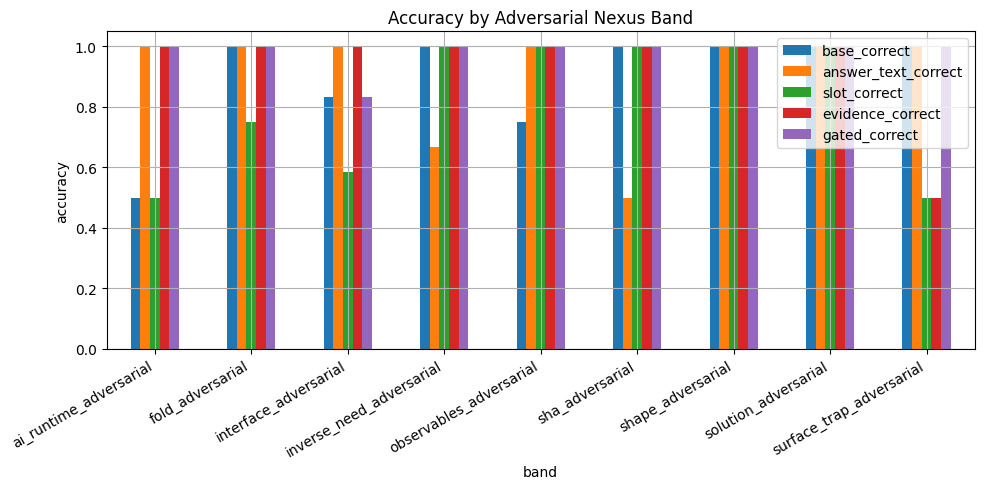

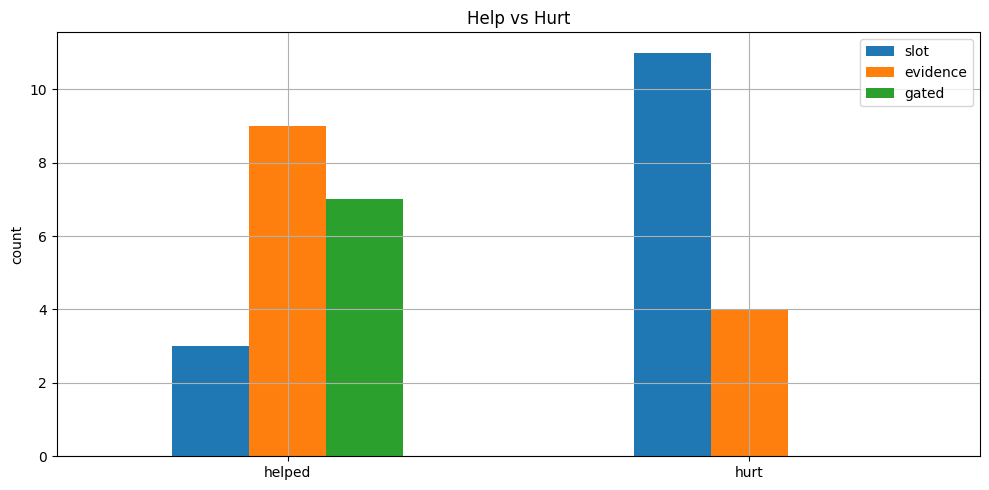

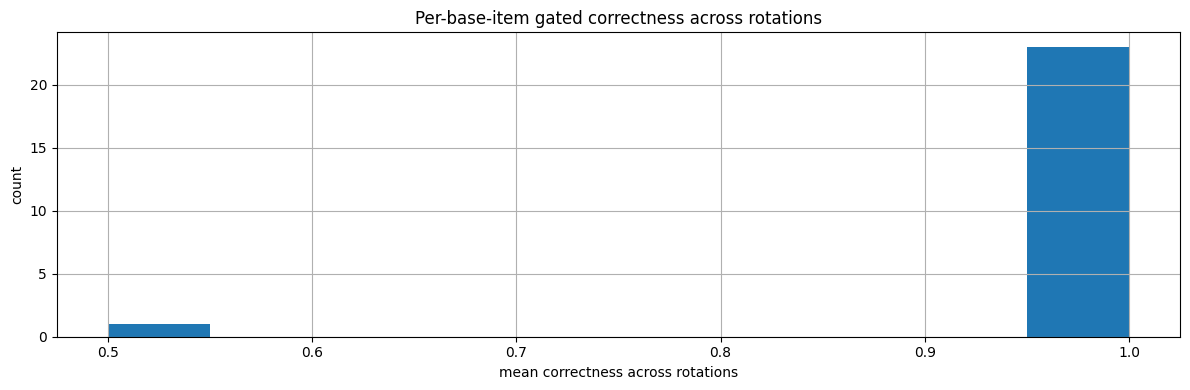

In [13]:
plt.figure(figsize=(11,4))
summary[["base_acc","answer_text_acc","slot_acc","evidence_acc","gated_acc"]].T.plot(kind="bar",legend=False)
plt.title("Accuracy by Scoring Mode")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,5))
by_band.set_index("band")[["base_correct","answer_text_correct","slot_correct","evidence_correct","gated_correct"]].plot(kind="bar")
plt.title("Accuracy by Adversarial Nexus Band")
plt.ylabel("accuracy")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "slot":[results_df.slot_helped.sum(),results_df.slot_hurt.sum()],
    "evidence":[results_df.evidence_helped.sum(),results_df.evidence_hurt.sum()],
    "gated":[results_df.gated_helped.sum(),results_df.gated_hurt.sum()],
},index=["helped","hurt"]).plot(kind="bar")
plt.title("Help vs Hurt")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
by_base_item["gated_correct"].hist(bins=10)
plt.title("Per-base-item gated correctness across rotations")
plt.xlabel("mean correctness across rotations")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [14]:
for row_id in interesting["id"].head(20):
    print("="*100)
    print("CASE:", row_id)
    display(results_df[results_df.id==row_id][["id","base_id","band","gold_choice","base_choice","base_correct","base_margin","answer_text_choice","answer_text_correct","answer_text_margin","slot_choice","slot_correct","slot_margin","slot_delta_vs_base","evidence_choice","evidence_correct","evidence_margin","evidence_delta_vs_base","gated_choice","gated_correct","gate_reason"]])
    print("NEED SLOT:")
    print(results_df[results_df.id==row_id]["need_slot_text"].iloc[0])
    display(evidence_tables[row_id].sort_values("energy"))


CASE: adv_car_01__rot0


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
8,adv_car_01__rot0,adv_car_01,interface_adversarial,"a readable driver surface: wheel, pedals, seat...",a semantic category called vehicle,0,5.125,"a readable driver surface: wheel, pedals, seat...",1,3.380859,...,0,0.404948,0.0,"a readable driver surface: wheel, pedals, seat...",1,0.44155,-0.404948,a semantic category called vehicle,0,protect_locked_base_slot_delta_weak


NEED SLOT:
required_operation: ...
preserved_function: ...
boundary_conditions: ...; ...
anti_fits: ...; ...
admissible_shape: ...
failure_modes: ...; ...


,choice_idx,choice,letter_score,answer_text_score,slot_bind_score,letter_z,text_z,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
1,1,"a readable driver surface: wheel, pedals, seat...",-23.828125,-2.486328,-2.313802,0.251293,1.702180,0.577829,0.683990,-0.874023,-1.305344,-1.523438,-2.578125,-2.289062,-2.304688,-1.960938,-3.226562
0,0,a semantic category called vehicle,-18.703125,-6.722656,-1.908854,1.529186,-0.850649,1.259819,0.690993,-0.075543,-0.863793,-0.375000,-1.570312,-1.851562,-2.867188,-1.757812,-3.031250
2,2,a detailed list of engine nouns,-28.078125,-5.867188,-2.940104,-0.808423,-0.335140,-0.476955,0.644973,-0.704102,0.387152,-2.015625,-3.421875,-2.781250,-2.546875,-3.281250,-3.593750
3,3,a symbol of transportation culture,-28.734375,-6.167969,-3.464844,-0.972056,-0.516392,-1.360692,0.584590,1.653668,1.781984,-3.148438,-3.484375,-3.164062,-3.343750,-3.453125,-4.195312


CASE: adv_car_01__rot1


...

,choice_idx,choice,letter_score,answer_text_score,slot_bind_score,letter_z,text_z,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
2,2,distributed constraint bias shaping the next-t...,-20.265625,-2.669922,-2.825521,0.240988,1.672019,0.913762,0.711350,-1.458122,-1.733973,-2.296875,-2.046875,-3.414062,-2.546875,-2.953125,-3.695312
3,3,a list of final answers,-23.671875,-8.046875,-2.632812,-1.080657,-0.859574,1.082071,0.648225,-0.276224,-0.242865,-1.171875,-1.992188,-2.671875,-3.539062,-3.023438,-3.398438
1,1,a non-computational object,-16.968750,-6.531250,-5.054688,1.520194,-0.145983,-1.033170,0.636692,1.250319,0.914121,-5.226562,-4.125000,-5.273438,-4.882812,-5.554688,-5.265625
0,0,a file of exact paragraphs,-22.640625,-7.636719,-4.973958,-0.680526,-0.666463,-0.962663,0.672805,0.484028,1.062717,-4.835938,-4.218750,-5.390625,-4.992188,-5.101562,-5.304688


CASE: adv_weight_01__rot3


,id,base_id,band,gold_choice,base_choice,base_correct,base_margin,answer_text_choice,answer_text_correct,answer_text_margin,...,slot_correct,slot_margin,slot_delta_vs_base,evidence_choice,evidence_correct,evidence_margin,evidence_delta_vs_base,gated_choice,gated_correct,gate_reason
91,adv_weight_01__rot3,adv_weight_01,ai_runtime_adversarial,distributed constraint bias shaping the next-t...,a non-computational object,0,0.875,distributed constraint bias shaping the next-t...,1,3.203125,...,0,0.192708,2.421875,distributed constraint bias shaping the next-t...,1,1.39117,2.229167,distributed constraint bias shaping the next-t...,1,override_text_evidence_slot_positive


NEED SLOT:
required_operation: ...
preserved_function: ...
boundary_conditions: ...; ...
anti_fits: ...; ...
admissible_shape: ...
failure_modes: ...; ...


,choice_idx,choice,letter_score,answer_text_score,slot_bind_score,letter_z,text_z,slot_z,pair_fit,contradiction_z,energy,slot_dim_required_operation,slot_dim_preserved_function,slot_dim_boundary_conditions,slot_dim_anti_fits,slot_dim_admissible_shape,slot_dim_failure_modes
1,1,distributed constraint bias shaping the next-t...,-19.875000,-3.027344,-2.825521,0.635689,1.626702,0.913762,0.700949,-1.427703,-1.760971,-2.296875,-2.046875,-3.414062,-2.546875,-2.953125,-3.695312
2,2,a list of final answers,-21.453125,-7.992188,-2.632812,-0.161883,-0.870325,1.082071,0.626834,-0.256306,-0.369801,-1.171875,-1.992188,-2.671875,-3.539062,-3.023438,-3.398438
0,0,a non-computational object,-19.000000,-6.230469,-5.054688,1.077907,0.015717,-1.033171,0.611455,1.330894,0.950254,-5.226562,-4.125000,-5.273438,-4.882812,-5.554688,-5.265625
3,3,a file of exact paragraphs,-24.203125,-7.796875,-4.973958,-1.551712,-0.772094,-0.962663,0.663248,0.353115,1.180519,-4.835938,-4.218750,-5.390625,-4.992188,-5.101562,-5.304688


## Readout

v53 is successful if:

$$
\text{gated\_acc} > \text{base\_acc}
$$

with:

$$
\text{gated\_hurt}=0
$$

The stronger signal is:

$$
\text{base wrong} \land \text{slot correct}
$$

because that means the generated need-slot is doing work before candidate scoring.

If slot accuracy is weak but gated stays safe, the slot generator is noisy but the architecture is valid.

If slot hurts many cases, the next fold is richer slot observables or a trained slot-builder.
